# Μέρος 1: Παρακολούθηση Προσώπου και Χεριών με Χρήση της Μεθόδου Οπτικής Ροής των Lucas-Kanade

In [140]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, ndimage, io

## 1.1 Ανίχνευση Δέρματος Προσώπου και Χεριών

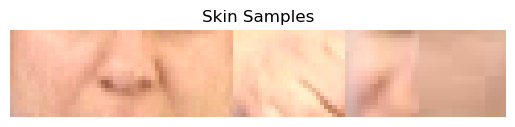

In [141]:
# Load skin samples and convert to YCbCr
mat = io.loadmat('part1_data/skinSamplesRGB.mat')
skinSamples = np.array(mat['skinSamplesRGB'])

plt.title('Skin Samples')
plt.imshow(skinSamples)
plt.axis('off')
plt.show()

skinSamples = cv2.cvtColor(skinSamples, cv2.COLOR_RGB2YCrCb)
del mat

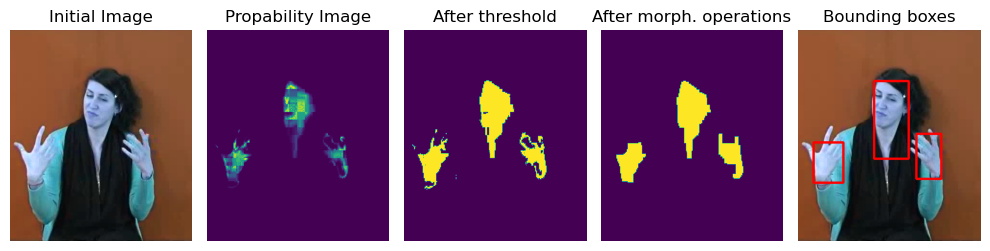

In [142]:
# Load first frame
imageRGB = cv2.imread('part1_data/1.png')
imageYCbCr = cv2.cvtColor(imageRGB, cv2.COLOR_BGR2YCrCb)
c = np.array([imageYCbCr[:,:,1].flatten(), imageYCbCr[:,:,2].flatten()])

# Calculate mean value and covariance matrix
Cb = skinSamples[:,:,1].flatten()
Cr = skinSamples[:,:,2].flatten()
mean_Cb = np.mean(Cb)
mean_Cr = np.mean(Cr)
mu = np.array([mean_Cb, mean_Cr])
sigma = np.cov(Cb, Cr)

# Calculate propability image
prob_image = stats.multivariate_normal(mean=mu, cov=sigma).pdf(c.T)
prob_image = prob_image.reshape(imageRGB.shape[0], imageRGB.shape[1])

# Apply threshold
_, prob_thres = cv2.threshold(prob_image, 0.0001, 1, cv2.THRESH_BINARY)

# Apply opening, then closing
open_kernel = np.ones((5, 5))
close_kernel = np.ones((20, 20), np.uint8)
prob_morph = cv2.morphologyEx(prob_thres, cv2.MORPH_OPEN, open_kernel)
prob_morph = cv2.morphologyEx(prob_morph, cv2.MORPH_CLOSE, close_kernel)
prob_morph = (prob_morph * 255).astype('uint8')

# Draw bounding boxes
image_out = imageRGB.copy()
_, contours, _ = cv2.findContours(prob_morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
for contour in contours:
    x, y, w, h = cv2.boundingRect(contour)
    cv2.rectangle(image_out, (x, y), (x+w, y+h), (255, 0, 0), 3)

# Plot steps 
plt.figure(figsize=(10, 3))
plt.subplot(1,5,1)
plt.title('Initial Image')
plt.imshow(imageRGB)
plt.axis('off')
plt.subplot(1,5,2)
plt.title('Propability Image')
plt.imshow(prob_image)
plt.axis('off')
plt.subplot(1,5,3)
plt.title('After threshold')
plt.imshow(prob_thres)
plt.axis('off')
plt.subplot(1,5,4)
plt.title('After morph. operations')
plt.imshow(prob_morph)
plt.axis('off')
plt.subplot(1,5,5)
plt.title('Bounding boxes')
plt.imshow(image_out)
plt.axis('off')
plt.tight_layout()
plt.show()

del imageRGB, imageYCbCr, c, prob_image, prob_thres, prob_morph, image_out, contours

Compose final function:

In [143]:
def SkinDetect(image, mean, cov):
    # Convert to YCbCr
    imageYCbCr = cv2.cvtColor(image, cv2.COLOR_BGR2YCrCb)

    # Calculate propability image
    c = np.array([imageYCbCr[:,:,1].flatten(), imageYCbCr[:,:,2].flatten()])
    prob_image = stats.multivariate_normal(mean, cov).pdf(c.T)
    prob_image = prob_image.reshape(image.shape[0], image.shape[1])

    # Apply threshold
    _, prob_thres = cv2.threshold(prob_image, 0.0001, 1, cv2.THRESH_BINARY)

    # Apply morphological operations
    open_kernel = np.ones((5, 5))
    close_kernel = np.ones((20, 20), np.uint8)
    prob_morph = cv2.morphologyEx(prob_thres, cv2.MORPH_OPEN, open_kernel)
    prob_morph = cv2.morphologyEx(prob_morph, cv2.MORPH_CLOSE, close_kernel)
    prob_morph = (prob_morph * 255).astype('uint8')

    # Draw bounding boxes
    _, contours, _ = cv2.findContours(prob_morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    bounding_boxes = [cv2.boundingRect(contour) for contour in contours]
    return bounding_boxes

## 1.2 Παρακολούθηση Προσώπου και Χεριών